# Optuna 하이퍼파라미터 튜닝
Team 반갑다모 | 2026.07.01

> top_n=60 피처 선택 결과 기반
> A_31: CW 강화 (class_weight={0:4,1:1,2:4})
> T_31: Baseline (class_weight='balanced')


## 0. 환경 설정

In [1]:
import sys
import subprocess

# 현재 커널 기준으로 설치
pkgs = ['lightgbm', 'optuna', 'koreanize-matplotlib', 'imbalanced-learn']
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True)

# 설치 확인
import importlib
for pkg in ['lightgbm', 'optuna', 'koreanize_matplotlib']:
    try:
        importlib.import_module(pkg)
        print(f'OK: {pkg}')
    except:
        print(f'FAIL: {pkg} -- 터미널에서 pip install {pkg} 후 커널 재시작 필요')

OK: lightgbm


C:\miniconda\envs\qaqc_st\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OK: optuna


OK: koreanize_matplotlib


In [2]:
import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, recall_score, confusion_matrix
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import spearmanr
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드 & top_n=60 피처 선택

In [3]:
a31 = pd.read_csv('A_31_preprocessed.csv', low_memory=False)
t31 = pd.read_csv('TO_31_preprocessed.csv', low_memory=False)

DROP_COLS = ['PRODUCT_ID', 'Y_Class', 'Y_Quality', 'TIMESTAMP', 'PRODUCT_CODE']

def get_XY(df):
    feat_cols = [c for c in df.columns if c not in DROP_COLS]
    return df[feat_cols], df['Y_Class'], df['Y_Quality']

X_a, y_a_cls, y_a_qlt = get_XY(a31)
X_t, y_t_cls, y_t_qlt = get_XY(t31)
print(f'A_31: {X_a.shape} | T_31: {X_t.shape}')

A_31: (316, 1966) | T_31: (592, 569)


In [4]:
def select_features(X, y_qlt, label, top_n=60):
    print(f'[{label}] 피처 선택 중 (top_n={top_n})...')
    imp = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
    feat_cols = [c for c in X_imp.columns if c.startswith('X_')]
    X_feat = X_imp[feat_cols]

    # Spearman
    sp_scores = {}
    for col in feat_cols:
        try:
            r, p = spearmanr(X_feat[col], y_qlt)
            if p < 0.05:
                sp_scores[col] = abs(r)
        except:
            pass
    sp_set = set([f for f, _ in
                  sorted(sp_scores.items(), key=lambda x: -x[1])[:top_n]])

    # MI
    mi_scores = mutual_info_regression(X_feat, y_qlt, random_state=42)
    mi_df = pd.DataFrame({'feature': feat_cols, 'mi': mi_scores})
    mi_set = set(mi_df.sort_values('mi', ascending=False).head(top_n)['feature'])

    # Lasso
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_feat)
    lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
    lasso.fit(X_scaled, y_qlt)
    lasso_coef = pd.Series(np.abs(lasso.coef_), index=feat_cols)
    lasso_set = set(lasso_coef[lasso_coef > 0].index)

    # 교집합 (2개 이상)
    from collections import Counter
    count = Counter([f for s in [sp_set, mi_set, lasso_set] for f in s])
    final_x = [f for f, c in count.items() if c >= 2]
    non_x = [c for c in X_imp.columns if not c.startswith('X_')]
    final = final_x + non_x
    print(f'  X_ 피처: {len(final_x)}개 | LINE 포함 최종: {len(final)}개')
    return final

selected_a = select_features(X_a, y_a_qlt, 'A_31', top_n=60)
selected_t = select_features(X_t, y_t_qlt, 'T_31+O_31', top_n=60)

X_a_sel = X_a[[c for c in selected_a if c in X_a.columns]]
X_t_sel = X_t[[c for c in selected_t if c in X_t.columns]]
print(f'\nA_31 학습 shape: {X_a_sel.shape}')
print(f'T_31 학습 shape: {X_t_sel.shape}')

[A_31] 피처 선택 중 (top_n=60)...


  X_ 피처: 31개 | LINE 포함 최종: 34개
[T_31+O_31] 피처 선택 중 (top_n=60)...


  X_ 피처: 24개 | LINE 포함 최종: 25개

A_31 학습 shape: (316, 34)
T_31 학습 shape: (592, 25)


## 2. 비교 기준 (top_n=60 순정 성능)

In [5]:
BASELINE = {
    'A_31':      {'macro_f1': 0.7211, 'recall_0': 0.7237, 'recall_2': 0.8444},
    'T_31+O_31': {'macro_f1': 0.6579, 'recall_0': 0.5417, 'recall_2': 0.4630},
}
print('비교 기준 (top_n=60 피처선택 후 순정 LightGBM):')
for k, v in BASELINE.items():
    print(f'  [{k}] F1={v["macro_f1"]:.4f} | R0={v["recall_0"]:.4f} | R2={v["recall_2"]:.4f}')

비교 기준 (top_n=60 피처선택 후 순정 LightGBM):
  [A_31] F1=0.7211 | R0=0.7237 | R2=0.8444
  [T_31+O_31] F1=0.6579 | R0=0.5417 | R2=0.4630


---
## 3. Optuna 튜닝 (n_trials=50)

In [6]:
def make_objective(X, y, cw, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
            'max_depth':         trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'class_weight': cw, 'random_state': 42, 'verbose': -1
        }
        oof = np.zeros(len(y))
        for tr_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            model = lgb.LGBMClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                 lgb.log_evaluation(-1)])
            oof[val_idx] = model.predict(X_val)
        return f1_score(y, oof, average='macro')
    return objective

N_TRIALS = 50

print(f'A_31 Optuna 시작 (n_trials={N_TRIALS})...')
study_a = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_a.optimize(make_objective(X_a_sel, y_a_cls, {0:4,1:1,2:4}),
                 n_trials=N_TRIALS, show_progress_bar=True)
print(f'A_31 최적 F1: {study_a.best_value:.4f}')
print(f'최적 파라미터: {study_a.best_params}')

print(f'\nT_31 Optuna 시작 (n_trials={N_TRIALS})...')
study_t = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_t.optimize(make_objective(X_t_sel, y_t_cls, 'balanced'),
                 n_trials=N_TRIALS, show_progress_bar=True)
print(f'T_31 최적 F1: {study_t.best_value:.4f}')
print(f'최적 파라미터: {study_t.best_params}')

A_31 Optuna 시작 (n_trials=50)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.736528:   0%|          | 0/50 [00:05<?, ?it/s]

Best trial: 0. Best value: 0.736528:   2%|▏         | 1/50 [00:05<04:37,  5.67s/it]

Best trial: 1. Best value: 0.758209:   2%|▏         | 1/50 [00:09<04:37,  5.67s/it]

...

Best trial: 16. Best value: 0.711359:  98%|█████████▊| 49/50 [01:06<00:01,  1.50s/it]

Best trial: 16. Best value: 0.711359:  98%|█████████▊| 49/50 [01:08<00:01,  1.50s/it]

Best trial: 16. Best value: 0.711359: 100%|██████████| 50/50 [01:08<00:00,  1.38s/it]

Best trial: 16. Best value: 0.711359: 100%|██████████| 50/50 [01:08<00:00,  1.36s/it]

T_31 최적 F1: 0.7114
최적 파라미터: {'n_estimators': 769, 'learning_rate': 0.12531998012975828, 'num_leaves': 114, 'max_depth': 11, 'min_child_samples': 5, 'subsample': 0.7580143193422604, 'colsample_bytree': 0.6341146568452845, 'reg_alpha': 1.0665857997367036e-05, 'reg_lambda': 1.314053143275926e-08}


---
## 4. 최적 파라미터로 최종 학습

In [7]:
def run_best(X, y, best_params, cw, label, n_splits=5):
    print(f'\n[{label}] 최적 파라미터로 학습')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros(len(y))
    imp_sum = np.zeros(X.shape[1])
    params = {**best_params, 'class_weight': cw, 'random_state': 42, 'verbose': -1}
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(-1)])
        oof[val_idx] = model.predict(X_val)
        imp_sum += model.feature_importances_
    f1 = f1_score(y, oof, average='macro')
    r0 = recall_score(y, oof, labels=[0], average='macro')
    r2 = recall_score(y, oof, labels=[2], average='macro')
    print(f'  Macro F1      : {f1:.4f}')
    print(f'  Class 0 Recall: {r0:.4f}')
    print(f'  Class 2 Recall: {r2:.4f}')
    return oof, imp_sum/n_splits, {'macro_f1': f1, 'recall_0': r0, 'recall_2': r2}

oof_a, imp_a, res_a = run_best(X_a_sel, y_a_cls, study_a.best_params, {0:4,1:1,2:4}, 'A_31')
oof_t, imp_t, res_t = run_best(X_t_sel, y_t_cls, study_t.best_params, 'balanced', 'T_31+O_31')


[A_31] 최적 파라미터로 학습


  Macro F1      : 0.7696
  Class 0 Recall: 0.7632
  Class 2 Recall: 0.8556

[T_31+O_31] 최적 파라미터로 학습


  Macro F1      : 0.7114
  Class 0 Recall: 0.5208
  Class 2 Recall: 0.4630


---
## 5. 전체 과정 성능 비교

In [8]:
print('=' * 62)
print('전체 과정 성능 비교')
print('=' * 62)

stages = {
    'A_31': [
        ('Baseline 순정',   0.6995, 0.6711, 0.7111),
        ('피처선택 top60',  0.7211, 0.7237, 0.8444),
        ('Optuna 튜닝',     res_a['macro_f1'], res_a['recall_0'], res_a['recall_2']),
    ],
    'T_31+O_31': [
        ('Baseline 순정',   0.6303, 0.3750, 0.3519),
        ('피처선택 top60',  0.6579, 0.5417, 0.4630),
        ('Optuna 튜닝',     res_t['macro_f1'], res_t['recall_0'], res_t['recall_2']),
    ]
}

for product, data in stages.items():
    print(f'\n[{product}]')
    print(f"  {'단계':15} {'Macro F1':>10} {'Class0 Recall':>14} {'Class2 Recall':>14}")
    print(f"  {'-'*57}")
    for stage, f1, r0, r2 in data:
        print(f'  {stage:15} {f1:>10.4f} {r0:>14.4f} {r2:>14.4f}')

전체 과정 성능 비교

[A_31]
  단계                Macro F1  Class0 Recall  Class2 Recall
  ---------------------------------------------------------
  Baseline 순정         0.6995         0.6711         0.7111
  피처선택 top60          0.7211         0.7237         0.8444
  Optuna 튜닝           0.7696         0.7632         0.8556

[T_31+O_31]
  단계                Macro F1  Class0 Recall  Class2 Recall
  ---------------------------------------------------------
  Baseline 순정         0.6303         0.3750         0.3519
  피처선택 top60          0.6579         0.5417         0.4630
  Optuna 튜닝           0.7114         0.5208         0.4630


---
## 6. 시각화

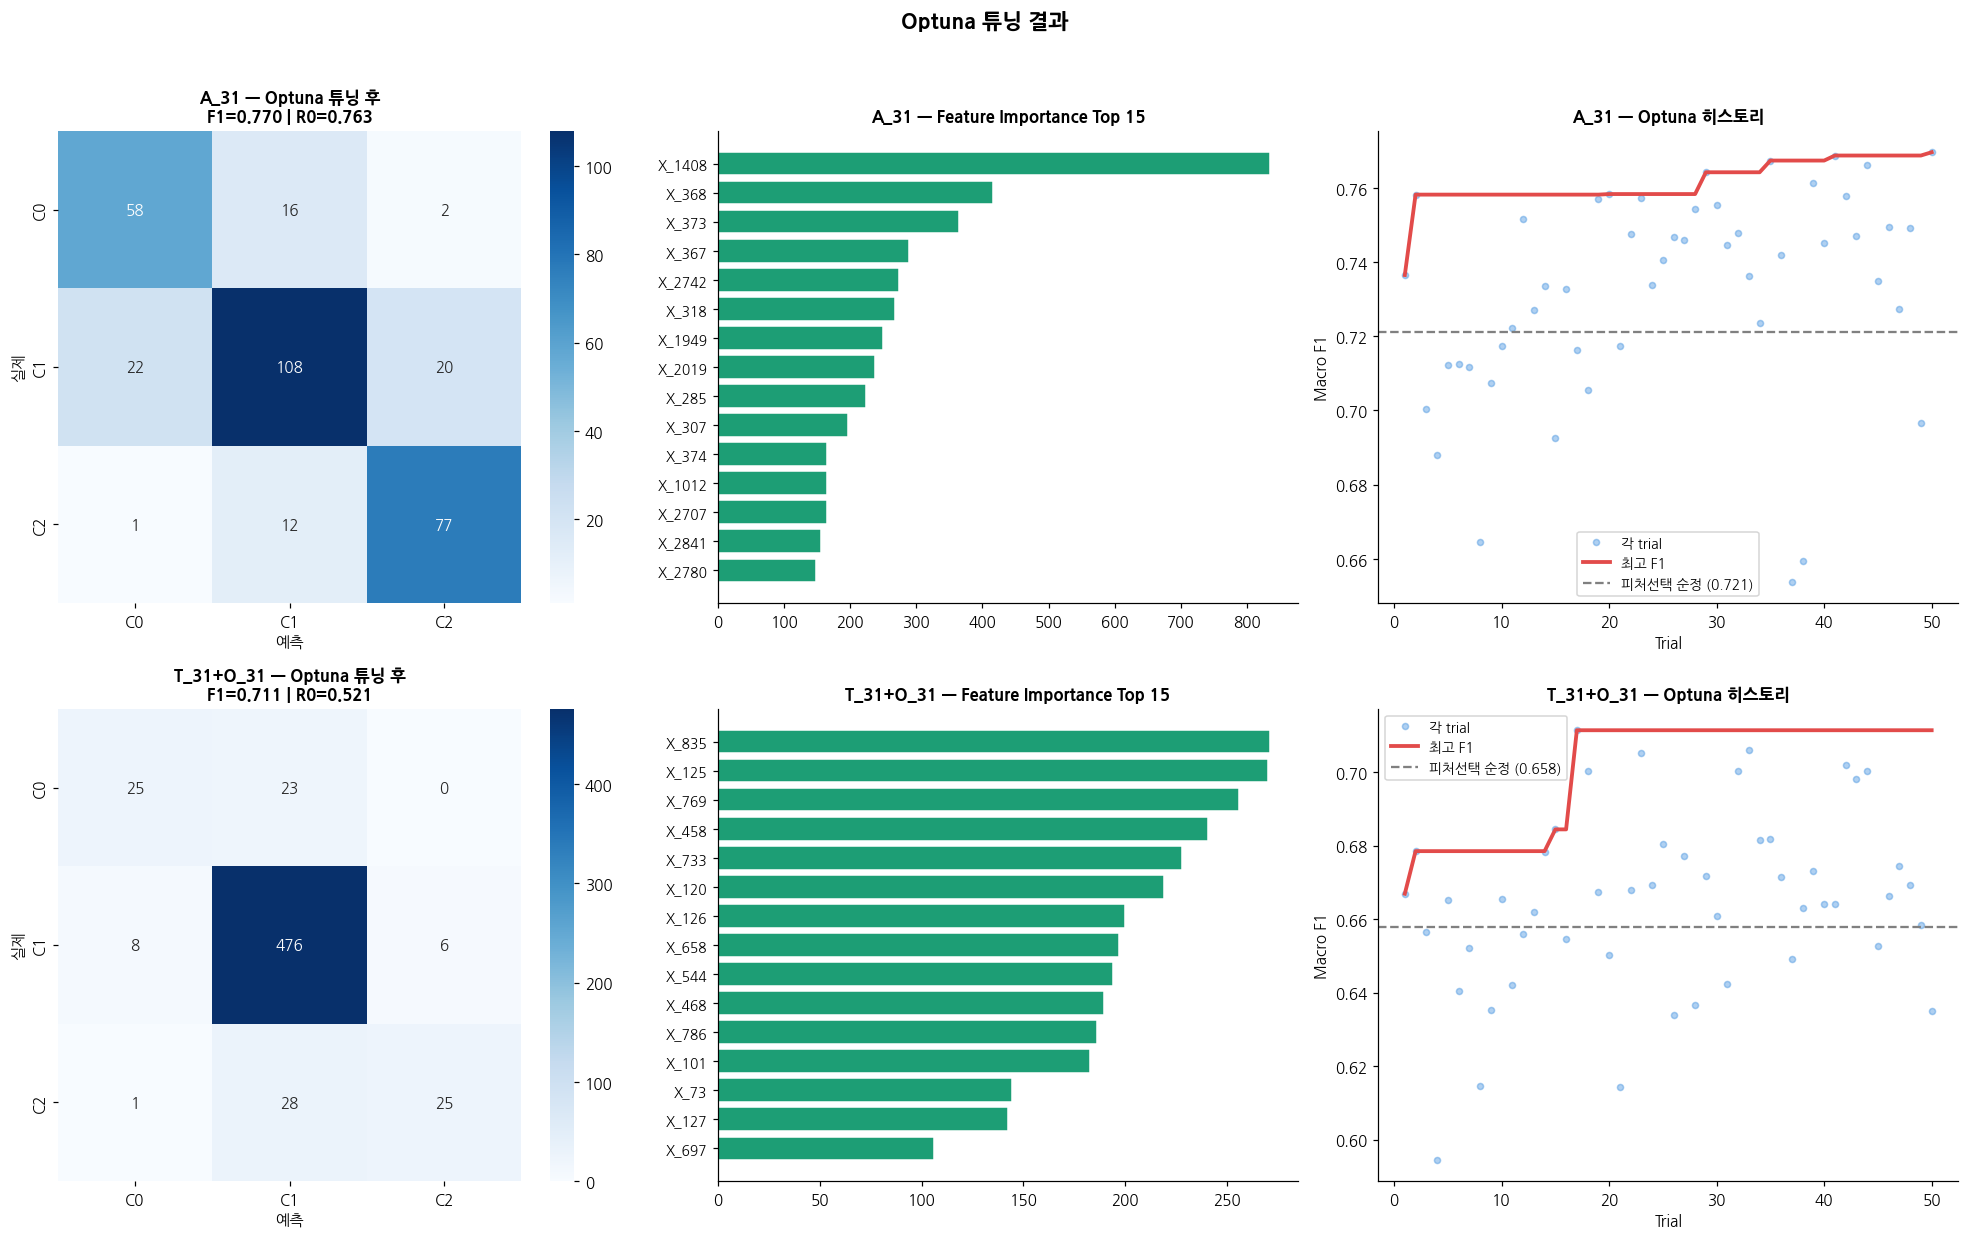

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for row, (product, y, oof, imp, X_sel, study) in enumerate([
    ('A_31',      y_a_cls, oof_a, imp_a, X_a_sel, study_a),
    ('T_31+O_31', y_t_cls, oof_t, imp_t, X_t_sel, study_t)
]):
    res = res_a if 'A' in product else res_t

    # Confusion Matrix
    ax = axes[row, 0]
    cm = confusion_matrix(y, oof)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['C0','C1','C2'],
                yticklabels=['C0','C1','C2'])
    ax.set_title(f'{product} — Optuna 튜닝 후\n'
                 f'F1={res["macro_f1"]:.3f} | R0={res["recall_0"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('실제')
    ax.set_xlabel('예측')

    # Feature Importance
    ax = axes[row, 1]
    imp_df = pd.DataFrame({'feature': X_sel.columns, 'importance': imp})
    imp_df = imp_df.sort_values('importance', ascending=False).head(15)
    ax.barh(range(len(imp_df)), imp_df['importance'].values,
            color='#1D9E75', edgecolor='white')
    ax.set_yticks(range(len(imp_df)))
    ax.set_yticklabels(imp_df['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{product} — Feature Importance Top 15',
                 fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Optuna 히스토리
    ax = axes[row, 2]
    trials = [t.value for t in study.trials if t.value is not None]
    best_so_far = [max(trials[:i+1]) for i in range(len(trials))]
    ax.plot(range(1, len(trials)+1), trials, 'o',
            color='#378ADD', alpha=0.4, markersize=4, label='각 trial')
    ax.plot(range(1, len(best_so_far)+1), best_so_far,
            color='#E24B4A', linewidth=2.5, label='최고 F1')
    bl = BASELINE[product]
    ax.axhline(bl['macro_f1'], color='gray', linestyle='--',
               linewidth=1.5, label=f'피처선택 순정 ({bl["macro_f1"]:.3f})')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Macro F1')
    ax.set_title(f'{product} — Optuna 히스토리',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Optuna 튜닝 결과', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. 인사이트 & 다음 단계

In [10]:
print('=' * 55)
print('Optuna 튜닝 종합 인사이트')
print('=' * 55)

for product, res, bl in [
    ('A_31',      res_a, BASELINE['A_31']),
    ('T_31+O_31', res_t, BASELINE['T_31+O_31'])
]:
    diff_f1 = res['macro_f1'] - bl['macro_f1']
    diff_r0 = res['recall_0'] - bl['recall_0']
    print(f'\n[{product}]')
    print(f'  F1  : {bl["macro_f1"]:.4f} -> {res["macro_f1"]:.4f} ({diff_f1:+.4f})')
    print(f'  R0  : {bl["recall_0"]:.4f} -> {res["recall_0"]:.4f} ({diff_r0:+.4f})')
    if diff_f1 > 0.01:
        print('  -> 튜닝 효과 있음!')
    elif diff_f1 >= 0:
        print('  -> 소폭 개선')
    else:
        print('  -> 튜닝 효과 미미. 앙상블로 보완 필요')

print('\n' + '=' * 55)
print('다음 단계')
print('=' * 55)
print('  -> 앙상블 가중치 최적화')
print('  -> SHAP 분석 (H1~H4 가설 검증)')

Optuna 튜닝 종합 인사이트

[A_31]
  F1  : 0.7211 -> 0.7696 (+0.0485)
  R0  : 0.7237 -> 0.7632 (+0.0395)
  -> 튜닝 효과 있음!

[T_31+O_31]
  F1  : 0.6579 -> 0.7114 (+0.0535)
  R0  : 0.5417 -> 0.5208 (-0.0209)
  -> 튜닝 효과 있음!

다음 단계
  -> 앙상블 가중치 최적화
  -> SHAP 분석 (H1~H4 가설 검증)
